#1. Установка и загрузка датасета через kagglehub


In [ ]:
!pip -q install kaggle

import kagglehub
from pathlib import Path

#Скачиваю последнюю версию датасета
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Путь к файлам датасета:", path)

data_dir = Path("/kaggle/input/chest-xray-pneumonia/chest_xray")

train_dir = data_dir / "train"
val_dir   = data_dir / "val"
test_dir  = data_dir / "test"

print("Путь к корневой папке с данными датасета:", data_dir.exists())
print("Путь к к папке с train данными:", train_dir)
print("Путь к к папке с val данными:", val_dir)
print("Путь к к папке с test данными:", test_dir)

In [ ]:
import os
print(os.listdir(data_dir))
print(os.listdir(train_dir))
print(os.listdir(train_dir / "PNEUMONIA")[:5])

In [ ]:
import random, numpy as np, torch

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#2.Анализ данных

2.1. Проверка дисбаланса классов

In [ ]:
def count_images(dir_path):
    normal_path = dir_path / "NORMAL" #создаю новый путь к подпапке NORMAL
    pneumonia_path = dir_path / "PNEUMONIA" #создаю новый путь к подпапке PNEUMONIA

    #подсчет кол-ва изображений обоих классов
    normal_count = len(list(normal_path.glob("*.jpeg")))
    pneumonia_count = len(list(pneumonia_path.glob("*.jpeg")))

    return normal_count, pneumonia_count

train_normal, train_pneumonia = count_images(train_dir)
val_normal, val_pneumonia = count_images(val_dir)
test_normal, test_pneumonia = count_images(test_dir)

print(f"Train: {train_normal + train_pneumonia} изображений (NORMAL: {train_normal}, PNEUMONIA: {train_pneumonia})")
print(f"Val:   {val_normal + val_pneumonia} изображений (NORMAL: {val_normal}, PNEUMONIA: {val_pneumonia})")
print(f"Test:  {test_normal + test_pneumonia} изображений (NORMAL: {test_normal}, PNEUMONIA: {test_pneumonia})")
print(f"\nДисбаланс в train: (PNEUMONIA/NORMAL) {train_pneumonia/train_normal:.2f}")

1)В данных пристуствует дисбаланс классов - доля класса PNEUMONIA заметно выше доли класса  NORMAL, из-за чего модель может смещаться в сторну предсказания пневмонии и указывать повышенную acсuracy при понижении качества на классе NORMAL.

**Для балансировки классов предлагаю использовать неагрессивные аугментацию  класса NORMAL в train датасете и использовать метод class weights**


2)Так же очень мала валидационная выборка, что затрудняет обучение. Оценка кач-ва будет иметь высокую дисперсию, из-за чего метрики loss, accuracy, f1 могут прыгать в значениях. Затруднительный подбор гиперпараметров, тк приходится подгонять модель под небольшую выборку изображений, из-за чего результат становится нестабильным.  

**Предлагаю создать новую валидационную выборку val_new, состоящую из 15% от train датасета.**

2.2. Проверка размеров изображений

In [ ]:
from PIL import Image
import random

def sample_image_sizes(dir_path, n_samples=25):
  #создаю список со всеми путями к изображениям из двух папок классов
    all_images = list((dir_path / "NORMAL").glob("*.jpeg")) + \
                 list((dir_path / "PNEUMONIA").glob("*.jpeg"))

    sample = random.sample(all_images, min(n_samples, len(all_images)))#случайный выбор изображений из all_images
    sizes = [Image.open(img).size for img in sample] #вывод размеров отобранных изображений - создается список размеров для всех файлов из sample

    return sizes #(width, height)

sizes = sample_image_sizes(train_dir, n_samples=50)#,беру 50 случайных изображений
width = [s[0] for s in sizes]
height = [s[1] for s in sizes]


print(f"Ширина:  min={min(width)}, max={max(width)}, avg={sum(width)/len(width):.0f}")
print(f"Высота:  min={min(height)}, max={max(height)}, avg={sum(height)/len(height):.0f}")


Размеры изображений разнятся - буду использовать resize до 224 х 224

Визуализация изображений

In [ ]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import numpy as np

# из аугментаций делаю только resize для визуализации изображений
resize_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

#создаю новый датасет
train_ds_resize = datasets.ImageFolder(root=train_dir, transform=resize_tfms)#создаю объект класса ImageFolder

#вытаскиваю индексы классов из словаря train_ds_resize.class_to_idx
NORMAL_IDX = train_ds_resize.class_to_idx["NORMAL"]
PNEUMONIA_IDX = train_ds_resize.class_to_idx["PNEUMONIA"]

#вывожу по 4е индекса обоих классов
normal_indices = np.where(np.array(train_ds_resize.targets) == NORMAL_IDX)[0][:4]
pneumonia_indices = np.where(np.array(train_ds_resize.targets) == PNEUMONIA_IDX)[0][:4]

#общий список индексов для визуализации
selected_indices = np.concatenate([normal_indices, pneumonia_indices])

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Примеры исходных снимков", fontsize=14)

for i, idx in enumerate(selected_indices):
    row = i // 4
    col = i % 4

    img, label = train_ds_resize[idx]
    img_np = img.permute(1, 2, 0).numpy()

    ax = axes[row, col]
    ax.imshow(img_np, cmap='gray')
    ax.set_title(f"{train_ds_resize.classes[label]} (idx={idx})")

plt.show()

2.3. Создаю новую валидационную выборку из train (беру 15%)

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

#беру изначальный датасет без аугментаций для получения меток классов(0 и 1) и индексов
base_ds = datasets.ImageFolder(root=train_dir, transform=None)

indices = np.arange(len(base_ds))#индексы всех изображений
targets = np.array(base_ds.targets)#метки класса для каждого индекса

#train_idx - массив индексов, выбранный для тренировочной части после разбиеняи на train и val
#val_idx - массив индексов, выбранный для валидационной части после разбиеняи на train и val
train_idx, val_idx = train_test_split(
    indices, #делю индексы элементов на train и val
    test_size=0.15,#15% на валидацию
    random_state=42,
    stratify=targets#сохраняю пропорции классов
)

print("Размер train:", len(train_idx))
print("Размер val:", len(val_idx))
print("Индекс метки класса:", base_ds.class_to_idx)

Далее создаю два датасета train и val для применения к ним соответсвующих аугментаций, тк у train и val разные требования по обработке

In [ ]:
#создаю нормализацию по imagenet
imagenet_norm = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std =[0.229, 0.224, 0.225]
)

In [ ]:
IMG_SIZE = 224

#аугментация для train датасета для метки NORMAL
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),#ресайз
    transforms.RandomHorizontalFlip(p=0.7),#отражение по-горизонтали с шансом 70%
    transforms.RandomRotation(10),#случайное вращение на 10 градусов
    transforms.ColorJitter(brightness=0.1, contrast=0.1),#яркость и контраст на 10%
    transforms.ToTensor(),#перевод в тензор
    imagenet_norm,
])

#предобработка для val
val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    imagenet_norm,
])

#изначальные датасеты из train_dir, с применением созданных аугментаций
normal_ds = datasets.ImageFolder(root=train_dir, transform=train_tfms)#беру трейн датасет и применяю аугментации для трейна
basic_ds = datasets.ImageFolder(root=train_dir, transform=val_tfms)#беру val датасет и применяю предобработку для валидации

#normal_ds - датасет с аугментациями, использую для расширения класса NORMAL
#basic_ds - датасет без случайных аугментаций(только с ресайзом и переводом в тензор), использую для val
#и для базовой части train на оба класса, чтоб модель при обучении хотя бы раз увидела ориганильные изображения без аугментаций


#создаю поддатасеты с трейн и валидационными даными
train_base_ds = Subset(basic_ds, train_idx)#трейн датасет с 85% данных от изначального трейн датасета train_dir с трансофрмациями val_tfms
val_ds = Subset(basic_ds, val_idx)#val датасет с 15% данных от изначального трейн датасета train_dir с трансофрмациями val_tfms

#далее добавляю только класс NORMAL из train_idx с аугментациями
normal_class_idx = basic_ds.class_to_idx["NORMAL"]#беру индекс класса NORMAL, то есть 0
train_targets = np.array(basic_ds.targets) #массив, в ктрм беру метки классов
normal_train_idx = train_idx[train_targets[train_idx] == normal_class_idx] #беру из train_idx только класс NORMAL с помощью булевой индексации

#создаю поддатасет с индексами из normal_train_idx, но с примененными трансформациями из normal_ds, а именно train_tfms(основная аугментация)
normal_train_aug = Subset(normal_ds, normal_train_idx)

#конечный трейн датасет с с базовым набором + доп копии класса NORMAL c аугментациями
from torch.utils.data import ConcatDataset
train_ds = ConcatDataset([train_base_ds, normal_train_aug])

print("Размер train_base_ds(85% от train_dir):", len(train_base_ds))
print("Размер val_ds(15% от train_dir):", len(val_ds))
print("Размер normal_train_aug(сколько NORMAL в train_idx):", len(normal_train_aug))
print("Размер финального train_ds:(длина базового набора данных + доп копии NORMAL с аугментациями)", len(train_ds))

Так же создам test dataset c предобработкой для валидации - resize + to tensor

In [ ]:
test_ds = datasets.ImageFolder(
    root = test_dir,
    transform = val_tfms
)

In [ ]:
print('Размер test_ds:', len(test_ds))

Визуализация аугментаций

In [ ]:
#денормализация для отображения картинок
def denorm(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1,2,0).numpy()
    img = img * std + mean
    return np.clip(img, 0, 1)

#беру 1 картинку из normal_ds и вывожу 6 аугментаций
fig, axes = plt.subplots(1, 6, figsize=(18, 3))

for i in range(6):
    x, y = normal_ds[5]  # всегда одну и ту же картинку
    axes[i].imshow(denorm(x))
    axes[i].set_title(f"Аугментация {i+1}", fontsize=14)
    axes[i].axis('off')

plt.suptitle("Примеры аугментаций для NORMAL (Flip/Rotate/Brightness)", fontsize=16)
plt.tight_layout()
plt.show()

#3 Создание и обучение моделей

3.1 Создаю Dataloader

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_ds,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = NUM_WORKERS,
    pin_memory = True
)

val_loader = DataLoader(
    val_ds,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = NUM_WORKERS,
    pin_memory = True
)

test_loader = DataLoader(
    test_ds,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = NUM_WORKERS,
    pin_memory = True
)

3.2 Модель ResNet18 с transfer learning

Загружаю предобученную модель ResNet18 и заменяю слой fc на 2 выхода (на два класса NORMAL и PNEUMONIA)

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torchvision import models

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
#перевожу обучение на gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

Создание Модели ResNet18 с fine tuning

In [ ]:
def make_resnet18 (num_classes = 2, freeze_backbone = True):
  weights = models.ResNet18_Weights.DEFAULT#загрузка модели с предобучеными весами
  model = models.resnet18(weights=weights)

#замораживаю все слои кроме классификатора
  if freeze_backbone:
    for param in model.parameters():
      param.requires_grad = False

  #заменяю последний полносвязный слой fc под 2 класса - NORMAL и PNEUMONIA
  in_features = model.fc.in_features
  model.fc = nn.Linear(in_features, num_classes)

  #обучаю последний слой
  for param in model.fc.parameters():
    param.requires_grad = True

  return model

Обучение модели ResNet18 и ее оценка

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
  model.train()

  all_losses = []#loss каждого батча
  all_preds = []#предсказанные классы по всем батчам
  all_targets = []#истинные метки классов по всем батчам

  for images, targets in loader:
    #images - тензоры изображений
    #targets - метки классов
    images = images.to(device, non_blocking=True)
    targets = targets.to(device, non_blocking=True)

    optimizer.zero_grad()#обнудение градиентов
    logits = model(images)#первоначальне выводы сети
    loss = criterion(logits, targets)#считаю loss между первоначальными предсказанием и истинной меткой
    loss.backward()#подсчет градиентов
    optimizer.step()#обновление весов модели, учитывая вычисленные градиенты
    all_losses.append(loss.item())#сохраняю loss батч для получения среднего значения за эпоху

    preds = torch.argmax(logits, dim = 1)#получаю предсказанный класс
    all_preds.append(preds.detach().cpu().numpy())#сохраняю предсказания
    all_targets.append(targets.detach().cpu().numpy())#сохраняю метки

  all_preds = np.concatenate(all_preds)#склеиваю батчи в один массив
  all_targets = np.concatenate(all_targets)#склеиваю батчи в один массив

  return float (np.mean(all_losses)), all_preds, all_targets


@torch.no_grad()#убираю отслежиавание градиентов, тк на валидации не делаю backward
def eval_one_epoch(model, loader, criterion, device):
    model.eval()

    all_losses = []
    all_probs_pos = []
    all_preds = []
    all_targets = []

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).long()

        logits = model(images)
        loss = criterion(logits, targets)
        all_losses.append(loss.item())

        probs = torch.softmax(logits, dim = 1) #вероятность по классам
        prob_pos = probs[:, 1] #вероятность положительного класса 1(PNEUMONIA)
        preds = torch.argmax(logits, dim = 1)

        all_probs_pos.append(prob_pos.cpu().numpy().astype(np.float32))
        all_preds.append(preds.cpu().numpy().astype(np.int64))
        all_targets.append(targets.cpu().numpy().astype(np.int64))

    yprob_val_pos = np.concatenate(all_probs_pos)
    yhat_val = np.concatenate(all_preds)
    y_val = np.concatenate(all_targets)

    return float(np.mean(all_losses)), y_val, yhat_val, yprob_val_pos

Запуск обучения модели ResNet18

In [ ]:
#создаю модель на 2 класса, заменяя слой fc на Linear
model = make_resnet18(num_classes = 2, freeze_backbone = True).to(device)

#loss для многоклассовой классификации
criterion = nn.CrossEntropyLoss()

#оптимизатор обучает только те параметры, для которых разрешено обучение (requires_grad=True), то есть те пармаметы, ктре не замораживали
optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr = 1e-3)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

NUM_EPOCHS = 10 #кол-во эпох
best_val_f1 = -1.0 #сюда сохраняю лучшее значение f1 на валидации(отрицательное значение
#заведомо хуже любого возможного значения f1, чтобы на первой же эпохе значение было бы заведомо наилучшим)
best_state = None #храение весов лучшей модели

for epoch in range(1, NUM_EPOCHS + 1):
  #обучение на train
    train_loss, y_train, yhat_train = train_one_epoch(model, train_loader, criterion, optimizer, device)
    #оценка на val
    val_loss, y_val, yhat_val, yprob_val_pos = eval_one_epoch(model, val_loader, criterion, device)
  #train_loss -  средний loss на трейн датасете за эпоху
  #y_train - массив с истинными метками классов для всех объектов
  #yhat_train - массив предсказанных модлеью меток классов

    #метрики качества на валидации
    val_acc = accuracy_score(y_val, yhat_val)#точность классификации - доля правильных предсказаний среди всех примеров
    val_prec = precision_score(y_val, yhat_val, zero_division=0)#точность положительного класса
    val_rec = recall_score(y_val, yhat_val, zero_division=0)#сколько из всех реально больных модель нашла больных
    val_f1 = f1_score(y_val, yhat_val, zero_division=0)#среднее precison и recall

   #roc-auc
    try:
        val_auc = roc_auc_score(y_val, yprob_val_pos)
    except Exception:
        val_auc = float("nan")


    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print(f"train_loss = {train_loss:.4f} | val_loss  ={val_loss:.4f}")
    print(f"val_acc = {val_acc:.4f} val_prec = {val_prec:.4f} val_rec = {val_rec:.4f} val_f1 = {val_f1:.4f} val_auc = {val_auc:.4f}")


    #сохраняю лучшую модель по F1 на валидации
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    scheduler.step()

print("Лучшее значение F1 на валидации:", best_val_f1)

#возвращаю лучшие веса в модель
if best_state is not None:
    model.load_state_dict(best_state)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 143MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10
train_loss = 0.2711 | val_loss  =0.1838
val_acc = 0.9361 val_prec = 0.9801 val_rec = 0.9330 val_f1 = 0.9560 val_auc = 0.9873


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 2/10
train_loss = 0.1610 | val_loss  =0.1260
val_acc = 0.9604 val_prec = 0.9808 val_rec = 0.9656 val_f1 = 0.9732 val_auc = 0.9916


...

Epoch 8/10
train_loss = 0.1158 | val_loss  =0.0934
val_acc = 0.9655 val_prec = 0.9727 val_rec = 0.9811 val_f1 = 0.9769 val_auc = 0.9941


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 9/10
train_loss = 0.1176 | val_loss  =0.0944
val_acc = 0.9642 val_prec = 0.9759 val_rec = 0.9759 val_f1 = 0.9759 val_auc = 0.9941


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 10/10
train_loss = 0.1215 | val_loss  =0.0960
val_acc = 0.9655 val_prec = 0.9760 val_rec = 0.9777 val_f1 = 0.9768 val_auc = 0.9938
Лучшее значение F1 на валидации: 0.9785407725321889


По ходу выполнения эпох val_loss падает, а val_f1 и val_auc растут, значит модель становится лучше на валидации(F1-score = 0.976, recall = 0.978). roc-auc около 0.99 - модель хорошо разделяет классы по вероятности в широком диапазоне порогов

Оценка на test данных

In [ ]:
test_loss, y_test, yhat_test, yprob_test_pos = eval_one_epoch(model, test_loader, criterion, device)

#метрики на тестовой выборке
test_acc  = accuracy_score(y_test, yhat_test)
test_prec = precision_score(y_test, yhat_test, zero_division=0)
test_rec  = recall_score(y_test, yhat_test, zero_division=0)
test_f1   = f1_score(y_test, yhat_test, zero_division=0)
test_auc  = roc_auc_score(y_test, yprob_test_pos)

print(f"test_loss = {test_loss:.4f}")
print(f"test_acc = {test_acc:.4f} | test_prec = {test_prec:.4f} | test_rec = {test_rec:.4f} | test_f1 = {test_f1:.4f} | test_auc = {test_auc:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


test_loss = 0.4373
test_acc = 0.8221 | test_prec = 0.7853 | test_rec = 0.9846 | test_f1 = 0.8737 | test_auc = 0.9367


test_acc = 0.8333 (accuracy) - доля правильных ответов чреди всех классов (модлеь часто ошибалась на NORMAL и давала ложную тревогу)

test_prec = 0.7955 (precision) — среди всех предсказаний “пневмония”  80% действительно пневмония TP и около 20% - ложная тревога FP, поэтому precision и accuracy ниже

test_rec = 0.9872 (recall) — среди всех реальных “пневмония” модель нашла почти все, то есть FN почти нет

test_f1 = 0.8810 (f1_score) - из-за того что recall имеет хорошее значение, а precision меньше - получил значение f1 < recall

test_auc = 0.9415 (roc-auc) —  разделение классов по вероятности хорошее, даже при большом кол-ве предсказаний ложных тревог FP. считается по вероятностям и показывает качество разделения классов при разных порогах


Создам матрицу ошибок

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

#матрица ошибок: строки = true, столбцы = pred
cm = confusion_matrix(y_test, yhat_test)
print("confusion_matrix:\n", cm)

#отчёт по метрикам по каждому классу
print(classification_report(y_test, yhat_test, target_names=["target 0", "target 1"]))

confusion_matrix:
 [[129 105]
 [  6 384]]
              precision    recall  f1-score   support

    target 0       0.96      0.55      0.70       234
    target 1       0.79      0.98      0.87       390

    accuracy                           0.82       624
   macro avg       0.87      0.77      0.79       624
weighted avg       0.85      0.82      0.81       624



TN = 135 (было 0, предсказали 0)

FP = 99 (было 0, предсказали 1)

FN = 5 (было 1, предсказали 0)

TP = 385 (было 1, предсказали 1)

очень много false positive ошибок, но очень мало false negative

recall(target 1) =  0.99 - почти все пневмонии найдены

precision(target 1) = 0.80 - 80% пнвемноний и правда пневмонии и примерно 20% “пневмоний” - ложные тревоги

recall(target 0) (срецифичность) = 0.58 - модель плохо распознаёт норму, потому что часто относит норму к пневмонии

далее я подберу порог на валидации для снижения ложно положительного FP значения ошибки. Нужно учитывать, что ложно отрицательная ошибка FN имеет хорошее значение и изменение порога может ухудшить этот важный показатель модели.

порог - число, с ктрм сравнивается вероятность класса PNEUMONIA. например, чем ниже порог, тем чаще модель будет выдавать класс PNEUMONIUM, так же снизится значение ложно негативной ошибки и recall будет расти, но будет больше ложно положительных ошибок FP и пониженный precison.
Если порог выше, то модель указывает класс PNEUMONIA когда сильно уверена в этом, что влечет за собой меньше ложно положительных FP ошибок и увеличенный precision, но больше ложно - негативных FN ошибок и пониженный recall, что недопустимо в моей задаче.

На данный момент, используя argmax, порог равен 0,5


Подбирать порог буду путем установления желаемого значения метрики recall по классу PNEUMONIA.

Подбор порога

выбрал минимальную целевую чувствительность(recall) для пропуска пневмонии в 97% (0.97), чтобы далее подобрать под него порог

In [ ]:
import numpy as np
from sklearn.metrics import recall_score

def recall_threshold(y_true, y_prob_pos, target_recall=0.97, n_grid=2001):
    thresholds = np.linspace(0.0, 1.0, n_grid)

    best = {"thr": None, "rec_pneu": -1.0, "spec_norm": -1.0}

    for thr in thresholds:
        y_pred = (y_prob_pos >= thr).astype(np.int64)#подсчет порога для каждого предсказания

        #recall по PNEUMONIA - если порог меньше target_recall, то такие пороги
        rec_pneu = recall_score(y_true, y_pred, pos_label=1, average="binary", zero_division=0)
        if rec_pneu < target_recall:
            continue

        #recall по NORMAL
        spec_norm = recall_score(y_true, y_pred, pos_label=0, average="binary", zero_division=0)

        if spec_norm > best["spec_norm"]:
            best = {"thr": float(thr), "rec_pneu": float(rec_pneu), "spec_norm": float(spec_norm)}

    return best

Оценка модели с новым порогом

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, roc_auc_score

def evaluate_with_threshold(y_true, y_prob_pos, thr):
    y_pred = (y_prob_pos >= thr).astype(np.int64)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        "acc": accuracy_score(y_true, y_pred),
        "prec": precision_score(y_true, y_pred, zero_division=0),
        "rec": recall_score(y_true, y_pred, pos_label=1, average="binary", zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob_pos),
        "cm": cm,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

In [ ]:
best = recall_threshold(y_val, yprob_val_pos, target_recall=0.97)
print("Выбранный порог:", best)

metrics_test = evaluate_with_threshold(y_test, yprob_test_pos, thr=best["thr"])
print(metrics_test)

Выбранный порог: {'thr': 0.592, 'rec_pneu': 0.9707903780068728, 'spec_norm': 0.945273631840796}
{'acc': 0.8365384615384616, 'prec': 0.8050847457627118, 'rec': 0.9743589743589743, 'f1': 0.8816705336426914, 'auc': np.float64(0.9366973482358099), 'cm': array([[142,  92],
       [ 10, 380]]), 'tn': 142, 'fp': 92, 'fn': 10, 'tp': 380}


До подбора порога: TN=135, FP=99, FN=5, TP=385

После порога: TN=139, FP=95, FN=6, TP=384

FN поднялась с 5 до 6 - всеравно хороший результат для такой важной метрики - (recall упал с 0,9872 до 0,9846)

ложные тревоги FP упали со 99 до 95, из-за чего precison увеличилось с 0,7955 до 0.8016

из-за того, что указал модели не пропускать пневмонию, вместе с этим она начала немного меньше делать ложных тревог, что повлияло так же на значение accuracy, которое поднялась с 0,8333 до 0,8381

recall немного снизился из-за того, что precision улучшился сильнее, чем упал recall

roc-auc не изменился, тк изменение порога на него не влияет, тк он считается по вероятностям(0.9415)

Итог: подбор порога позволил уменьшить ложную тревогу FP и повысить метрики precision и accuracy

Grad CAM по ResNet18

In [ ]:
!pip -q install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 33.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Истинная метка: 1 Целевой класс в gradcam: 1


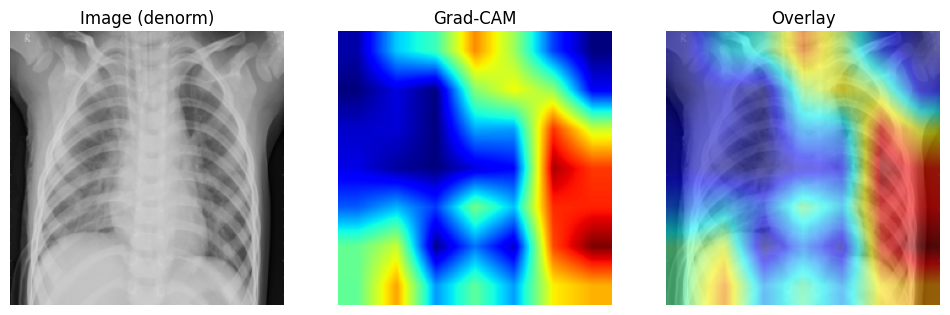

In [ ]:
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


def gradcam_resnet18(model, input_tensor, rgb_image_float01, target_class=None, device="cuda"):
    torch.set_grad_enabled(True)
    #model - модель resnet18
    #input_tensor -  тензор формы [1,3,224,224] после всех трансформов
    #rgb_image_float01 - numpy array shape [224,224,3]
    #target_class - индекс класса для которого строю карту

    model.eval()
    model.to(device)
    input_tensor = input_tensor.to(device)
    input_tensor.requires_grad_(True)

    #для ResNet18 беру последний сверточный блок layer4
    target_layers = [model.layer4]

    cam = GradCAM(model=model, target_layers=target_layers)

    if target_class is None:
        with torch.no_grad():
            logits = model(input_tensor)
            target_class = int(torch.argmax(logits, dim=1).item())

    targets = [ClassifierOutputTarget(target_class)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]

    visualization = show_cam_on_image(rgb_image_float01, grayscale_cam, use_rgb=True)
    return target_class, grayscale_cam, visualization

#пример: 1 изображение из test_ds
device = "cuda" if torch.cuda.is_available() else "cpu"

idx = 600
x, y = test_ds[idx]
input_tensor = x.unsqueeze(0)


#денормализация изображений(возвращаю изображения в привычный вид)
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

img = x.detach().cpu().permute(1, 2, 0).numpy().astype(np.float32)
img = img * std + mean
img = np.clip(img, 0.0, 1.0)


#построение grad cam для класса PNEUMONIA
target_class, cam_map, overlay = gradcam_resnet18(
    model, input_tensor, img,
    target_class=1,
    device=device
)

print("Истинная метка:", int(y), "Целевой класс в gradcam:", target_class)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.title("Image (denorm)"); plt.imshow(img); plt.axis("off")
plt.subplot(1, 3, 2); plt.title("Grad-CAM"); plt.imshow(cam_map, cmap="jet"); plt.axis("off")
plt.subplot(1, 3, 3); plt.title("Overlay"); plt.imshow(overlay); plt.axis("off")
plt.show()

Для дальнейших моделей я буду использовать те же созданные ранее датасеты с теми же аугментациями и трансформациями и тот же фиксмрованный recall 0.97.
На остальных моделях буду так же считать матрицуу ошибокк и метрики при полученном пороге. Сравнивать модели буду по FN, FP и auc

3.3 Создание модели ResNet50 с fine tuning

In [ ]:
def make_resnet50 (num_classes = 2, freeze_backbone = True):
  weights = models.ResNet50_Weights.DEFAULT#загрузка модели с предобучеными весами
  model = models.resnet50(weights=weights)

#замораживаю все слои кроме классификатора
  if freeze_backbone:
    for param in model.parameters():
      param.requires_grad = False

  #заменяю последний полносвязный слой fc под 2 класса - NORMAL и PNEUMONIA
  in_features = model.fc.in_features
  model.fc = nn.Linear(in_features, num_classes)

  #обучаю последний слой
  for param in model.fc.parameters():
    param.requires_grad = True

  return model

Обучение модели ResNet50

(функции обчения train_one_epoch и eval_one_epoch остаются прежними с обучения resnet18)

Запуск обучения модели ResNet50

In [ ]:
#создаю модель на 2 класса, заменяя слой fc на линейный полносвязный слой Linear
model50 = make_resnet50(num_classes = 2, freeze_backbone = True).to(device)

#loss для многоклассовой классификации
criterion = nn.CrossEntropyLoss()

#оптимизатор обучает только те параметры, для которых разрешено обучение (requires_grad=True), то есть те пармаметы, ктре не замораживали
optimizer50 = Adam(filter(lambda p: p.requires_grad, model50.parameters()), lr = 1e-3)

scheduler50 = torch.optim.lr_scheduler.StepLR(optimizer50, step_size=2, gamma=0.5)

NUM_EPOCHS = 10 #кол-во эпох
best_val_f1_50 = -1.0 #сюда сохраняю лучшее значение f1 на валидации(отрицательное значение
#заведомо хуже любого возможного значения f1, чтобы на первой же эпохе значение было бы заведомо наилучшим)
best_state50 = None #хранение весов лучшей модели

for epoch in range(1, NUM_EPOCHS + 1):
  #обучение на train
    train_loss, y_train, yhat_train = train_one_epoch(model50, train_loader, criterion, optimizer50, device)
    #оценка на val
    val_loss, y_val, yhat_val, yprob_val_pos = eval_one_epoch(model50, val_loader, criterion, device)
  #train_loss -  средний loss на трейн датасете за эпоху
  #y_train - массив с истинными метками классов для всех объектов
  #yhat_train - массив предсказанных модлеью меток классов

    #метрики качества на валидации
    val_acc = accuracy_score(y_val, yhat_val)#точность классификации - доля правильных предсказаний среди всех примеров
    val_prec = precision_score(y_val, yhat_val, zero_division=0)#точность положительного класса
    val_rec = recall_score(y_val, yhat_val, zero_division=0)#сколько из всех реально больных модель нашла больных
    val_f1 = f1_score(y_val, yhat_val, zero_division=0)#среднее precison и recall

   #roc-auc
    try:
        val_auc = roc_auc_score(y_val, yprob_val_pos)
    except Exception:
        val_auc = float("nan")


    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print(f"train_loss = {train_loss:.4f} | val_loss  ={val_loss:.4f}")
    print(f"val_acc = {val_acc:.4f} val_prec = {val_prec:.4f} val_rec = {val_rec:.4f} val_f1 = {val_f1:.4f} val_auc = {val_auc:.4f}")


    #сохраняю лучшую модель по F1 на валидации
    if val_f1 > best_val_f1_50:
        best_val_f1_50 = val_f1
        best_state50 = {k: v.cpu().clone() for k, v in model50.state_dict().items()}

    scheduler50.step()

print("Лучшее значение F1 на валидации:", best_val_f1_50)

#возвращаю лучшие веса в модель
if best_state50 is not None:
    model50.load_state_dict(best_state50)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 150MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10
train_loss = 0.2720 | val_loss  =0.1825
val_acc = 0.9387 val_prec = 0.9668 val_rec = 0.9502 val_f1 = 0.9584 val_auc = 0.9798


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 2/10
train_loss = 0.1616 | val_loss  =0.1518
val_acc = 0.9400 val_prec = 0.9421 val_rec = 0.9794 val_f1 = 0.9604 val_auc = 0.9848


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 4/10
train_loss = 0.1347 | val_loss  =0.1322
val_acc = 0.9476 val_prec = 0.9608 val_rec = 0.9691 val_f1 = 0.9649 val_auc = 0.9877


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 5/10
train_loss = 0.1232 | val_loss  =0.1456
val_acc = 0.9438 val_prec = 0.9786 val_rec = 0.9450 val_f1 = 0.9615 val_auc = 0.9890


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


По ходу выполнения эпох val_loss падает, а val_f1 и val_auc растут, значит модель становится лучше на валидации(F1-score = 0.976, recall = 0.978). roc-auc около 0.99 - модель хорошо разделяет классы по вероятности в широком диапазоне порогов

Оценка на test данных

In [ ]:
test_loss, y_test, yhat_test, yprob_test_pos = eval_one_epoch(model50, test_loader, criterion, device)

#метрики на тестовой выборке
test_acc  = accuracy_score(y_test, yhat_test)
test_prec = precision_score(y_test, yhat_test, zero_division=0)
test_rec  = recall_score(y_test, yhat_test, zero_division=0)
test_f1   = f1_score(y_test, yhat_test, zero_division=0)
test_auc  = roc_auc_score(y_test, yprob_test_pos)

print(f"test_loss = {test_loss:.4f}")
print(f"test_acc = {test_acc:.4f} | test_prec = {test_prec:.4f} | test_rec = {test_rec:.4f} | test_f1 = {test_f1:.4f} | test_auc = {test_auc:.4f}")

test_acc = 0.8225 (accuracy) - доля правильных ответов среди всех классов (модлеь часто ошибалась на NORMAL и давала ложную тревогу)

test_prec = 0.7882 (precision) — среди всех предсказаний “пневмония”  78% действительно пневмония TP и около 22% - ложная тревога FP, поэтому precision и accuracy ниже

test_rec = 0.9923 (recall) — среди всех реальных “пневмония” модель нашла почти все, то есть FN почти нет

test_f1 = 0.8785 (f1_score) - из-за того что recall имеет хорошее значение, а precision меньше - получил значение f1 < recall

test_auc = 0.9431 (roc-auc) —  разделение классов по вероятности хорошее, даже при большом кол-ве предсказаний ложных тревог FP. считается по вероятностям и показывает качество разделения классов при разных порогах


Модель сильно осторожничает - боится пропустить пневмонию и делает много ложных срабатываний.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

#матрица ошибок: строки = true, столбцы = pred
cm = confusion_matrix(y_test, yhat_test)
print("confusion_matrix:\n", cm)

#отчёт по метрикам по каждому классу
print(classification_report(y_test, yhat_test, target_names=["target 0", "target 1"]))

TN = 130 (было 0, предсказали 0)

FP = 104 (было 0, предсказали 1)

FN = 3 (было 1, предсказали 0)

TP = 387 (было 1, предсказали 1)

очень много false positive ошибок, но очень мало false negative

recall(target 1) =  0.99 - почти все пневмонии найдены

precision(target 1) = 0.79 - 79% пнвемноний и правда пневмонии и примерно 21% “пневмоний” - ложные тревоги

recall(target 0) (срецифичность) = 0.56 - модель плохо распознаёт норму, потому что часто относит норму к пневмонии

далее я подберу порог на валидации для снижения ложно положительного FP значения ошибки. Нужно учитывать, что ложно отрицательная ошибка FN имеет хорошее значение и изменение порога может ухудшить этот важный показатель модели.

порог - число, с ктрм сравнивается вероятность класса PNEUMONIA. например, чем ниже порог, тем чаще модель будет выдавать класс PNEUMONIUM, так же снизится значение ложно негативной ошибки и recall будет расти, но будет больше ложно положительных ошибок FP и пониженный precison.
Если порог выше, то модель указывает класс PNEUMONIA когда сильно уверена в этом, что влечет за собой меньше ложно положительных FP ошибок и увеличенный precision, но больше ложно - негативных FN ошибок и пониженный recall, что недопустимо в моей задаче.

На данный момент, используя argmax, порог равен 0,5


Подбирать порог буду путем установления желаемого значения метрики recall по классу PNEUMONIA.

Подбор порога

выбрал минимальную целевую чувствительность(recall) для пропуска пневмонии в 97% (0.97), чтобы далее подобрать под него порог

In [ ]:
import numpy as np
from sklearn.metrics import recall_score

def recall_threshold(y_true, y_prob_pos, target_recall=0.97, n_grid=2001):
    thresholds = np.linspace(0.0, 1.0, n_grid)

    best = {"thr": None, "rec_pneu": -1.0, "spec_norm": -1.0}

    for thr in thresholds:
        y_pred = (y_prob_pos >= thr).astype(np.int64)#подсчет порога для каждого предсказания

        #recall по PNEUMONIA - если порог меньше target_recall, то такие пороги
        rec_pneu = recall_score(y_true, y_pred, pos_label=1, average="binary", zero_division=0)
        if rec_pneu < target_recall:
            continue

        #recall по NORMAL
        spec_norm = recall_score(y_true, y_pred, pos_label=0, average="binary", zero_division=0)

        if spec_norm > best["spec_norm"]:
            best = {"thr": float(thr), "rec_pneu": float(rec_pneu), "spec_norm": float(spec_norm)}

    return best

Оценка модели с новым порогом

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, roc_auc_score

def evaluate_with_threshold(y_true, y_prob_pos, thr):
    y_pred = (y_prob_pos >= thr).astype(np.int64)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        "acc": accuracy_score(y_true, y_pred),
        "prec": precision_score(y_true, y_pred, zero_division=0),
        "rec": recall_score(y_true, y_pred, pos_label=1, average="binary", zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob_pos),
        "cm": cm,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

In [ ]:
best50 = recall_threshold(y_val, yprob_val_pos, target_recall=0.97)
print("Выбранный порог:", best50)

metrics_test50 = evaluate_with_threshold(y_test, yprob_test_pos, thr=best50["thr"])
print(metrics_test50)

До подбора порога: TN=130, FP=104, FN=3, TP=387

После порога: TN=108, FP=126, FN=2, TP=388

FN упала с 3 до 2 - хороший результат для такой важной метрики - (recall поднялся с 0,9923 до 0,9948)

ложные тревоги FP повысились со 104 до 126, из-за чего precison упал с 0,7882 до 0.7548

из-за того, что указал модели не пропускать пневмонию, вместе с этим она начала больше делать ложных тревог, что повлияло так же на значение accuracy, которое упало с 0,8285 до 0,7948

recall немного увеличился из-за того, что precision упал сильнее, чем увеличился recall

roc-auc не изменился, тк изменение порога на него не влияет, тк он считается по вероятностям(0.9431)

Итог: подбор порога увеличил ложную тревогу FP и снизил ложные негативные ошибки, тем самым поднял метрику recall.

Grad CAM по ResNet50

In [ ]:
def gradcam_resnet50(model50, input_tensor, rgb_image_float01, target_class=1, device="cuda"):
    torch.set_grad_enabled(True)
    #model - модель resnet50
    #input_tensor -  тензор формы [1,3,224,224] после всех трансформов
    #rgb_image_float01 - numpy array shape [224,224,3]
    #target_class - индекс класса для которого строю карту

    model50.eval()
    model50.to(device)
    input_tensor = input_tensor.to(device)
    input_tensor.requires_grad_(True)

    #для ResNet50 беру последний сверточный блок в слое layer4
    target_layers = [model50.layer4[-1]]

    cam = GradCAM(model=model50, target_layers=target_layers)

    if target_class is None:
        with torch.no_grad():
            logits = model50(input_tensor)
            target_class = int(torch.argmax(logits, dim=1).item())

    targets = [ClassifierOutputTarget(target_class)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]

    visualization = show_cam_on_image(rgb_image_float01, grayscale_cam, use_rgb=True)
    return target_class, grayscale_cam, visualization

#пример: 1 изображение из test_ds
device = "cuda" if torch.cuda.is_available() else "cpu"

idx = 600
x, y = test_ds[idx]
input_tensor = x.unsqueeze(0)


#денормализация изображений(возвращаю изображения в привычный вид)
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

img = x.detach().cpu().permute(1, 2, 0).numpy().astype(np.float32)
img = img * std + mean
img = np.clip(img, 0.0, 1.0)


#построение grad cam для класса PNEUMONIA
target_class, cam_map, overlay = gradcam_resnet50(
    model50, input_tensor, img,
    target_class=1,
    device=device
)

print("Истинная метка:", int(y), "Целевой класс в gradcam:", target_class)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.title("Image (denorm)"); plt.imshow(img); plt.axis("off")
plt.subplot(1, 3, 2); plt.title("Grad-CAM"); plt.imshow(cam_map, cmap="jet"); plt.axis("off")
plt.subplot(1, 3, 3); plt.title("Overlay"); plt.imshow(overlay); plt.axis("off")
plt.show()

3.4 Модель DenseNet121

In [ ]:
def make_densenet121 (num_classes = 2, freeze_backbone = True):
    weights = models.DenseNet121_Weights.DEFAULT#беру предобученную модель с весами imagenet на 1000 классов
    model = models.densenet121(weights=weights)

    #замораживаю все слои кроме классификатора
    if freeze_backbone:
      for param in model.features[:4].parameters():#замораживаю начальный блок - conv0, norm0, relu0 и pool0
        param.requires_grad = False

    #заменяю последний полносвязный слой classifier под 2 класса - NORMAL и PNEUMONIA
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)

    #обучаю последний слой
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model

Обучение модели DenseNet121


In [ ]:
#создаю модель на 2 класса, заменяя слой fc на Linear
model121 = make_densenet121(num_classes = 2, freeze_backbone = True).to(device)

#loss для многоклассовой классификации
criterion = nn.CrossEntropyLoss()

#оптимизатор обучает только те параметры, для которых разрешено обучение (requires_grad=True), то есть те пармаметы, ктре не замораживали
optimizer121 = Adam(filter(lambda p: p.requires_grad, model121.parameters()), lr = 1e-3)

scheduler121 = torch.optim.lr_scheduler.StepLR(optimizer121, step_size=2, gamma=0.5)

NUM_EPOCHS = 10 #кол-во эпох
best_val_f1_121 = -1.0 #сюда сохраняю лучшее значение f1 на валидации(отрицательное значение
#заведомо хуже любого возможного значения f1, чтобы на первой же эпохе значение было бы заведомо наилучшим)
best_state121 = None #хранение весов лучшей модели

for epoch in range(1, NUM_EPOCHS + 1):
  #обучение на train
    train_loss, y_train, yhat_train = train_one_epoch(model121, train_loader, criterion, optimizer121, device)
    #оценка на val
    val_loss, y_val, yhat_val, yprob_val_pos = eval_one_epoch(model121, val_loader, criterion, device)
  #train_loss -  средний loss на трейн датасете за эпоху
  #y_train - массив с истинными метками классов для всех объектов
  #yhat_train - массив предсказанных модлеью меток классов

    #метрики качества на валидации
    val_acc = accuracy_score(y_val, yhat_val)#точность классификации - доля правильных предсказаний среди всех примеров
    val_prec = precision_score(y_val, yhat_val, zero_division=0)#точность положительного класса
    val_rec = recall_score(y_val, yhat_val, zero_division=0)#сколько из всех реально больных модель нашла больных
    val_f1 = f1_score(y_val, yhat_val, zero_division=0)#среднее precison и recall

   #roc-auc
    try:
        val_auc = roc_auc_score(y_val, yprob_val_pos)
    except Exception:
        val_auc = float("nan")


    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print(f"train_loss = {train_loss:.4f} | val_loss  ={val_loss:.4f}")
    print(f"val_acc = {val_acc:.4f} val_prec = {val_prec:.4f} val_rec = {val_rec:.4f} val_f1 = {val_f1:.4f} val_auc = {val_auc:.4f}")


    #сохраняю лучшую модель по F1 на валидации
    if val_f1 > best_val_f1_121:
        best_val_f1_121 = val_f1
        best_state121 = {k: v.cpu().clone() for k, v in model121.state_dict().items()}

    scheduler121.step()

print("Лучшее значение F1 на валидации:", best_val_f1_121)

#возвращаю лучшие веса в модель
if best_state121 is not None:
    model121.load_state_dict(best_state121)


значение val_loss скачет - обучение несабильное. roc-auc 0.99 - модель хорошо разделяет классы по вероятности в широком диапазоне порогов.

Оценка на test данных

In [ ]:
test_loss, y_test, yhat_test, yprob_test_pos = eval_one_epoch(model121, test_loader, criterion, device)

#метрики на тестовой выборке
test_acc  = accuracy_score(y_test, yhat_test)
test_prec = precision_score(y_test, yhat_test, zero_division=0)
test_rec  = recall_score(y_test, yhat_test, zero_division=0)
test_f1   = f1_score(y_test, yhat_test, zero_division=0)
test_auc  = roc_auc_score(y_test, yprob_test_pos)

print(f"test_loss = {test_loss:.4f}")
print(f"test_acc = {test_acc:.4f} | test_prec = {test_prec:.4f} | test_rec = {test_rec:.4f} | test_f1 = {test_f1:.4f} | test_auc = {test_auc:.4f}")

Ошибка на тесте test_loss слишком большая (1.1886) и учитывая размерность ошибки на валидации и ее скачки, могу сделать вывод о переобучении модели. Модель ошибается слишком часто ошибается в тестовых снимках, а именно ставит высокую вероятность пневмонии, там где ее нет - много ложных срабатываний.

test_acc = 0.7949 (accuracy) - доля правильных ответов среди всех классов (модель часто ошибалась на NORMAL и давала ложную тревогу)

test_prec = 0.7529 (precision) — среди всех предсказаний “пневмония”  74% действительно пневмония TP и около 26% - ложная тревога FP, поэтому precision и accuracy ниже

test_rec = 1 (recall) — среди всех реальных “пневмония” модель нашла все, то есть FN почти нет

test_f1 = 0.8590 (f1_score) - из-за того что recall имеет хорошее значение, а precision меньше - получил значение f1 < recall

test_auc = 0.9486 (roc-auc) —  разделение классов по вероятности хорошее, даже при большом кол-ве предсказаний ложных тревог FP. считается по вероятностям и показывает качество разделения классов при разных порогах


Есть явные признаки переобучения модели.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

#матрица ошибок: строки = true, столбцы = pred
cm = confusion_matrix(y_test, yhat_test)
print("confusion_matrix:\n", cm)

#отчёт по метрикам по каждому классу
print(classification_report(y_test, yhat_test, target_names=["target 0", "target 1"]))

TN = 106 (было 0, предсказали 0)

FP = 128 (было 0, предсказали 1)

FN = 0 (было 1, предсказали 0)

TP = 390 (было 1, предсказали 1)

очень много false positive ошибок, но очень мало false negative

recall(target 1) =  1.00 - все пневмонии найдены

precision(target 1) = 0.75 - 75% пневмноний и правда пневмонии и примерно 25% “пневмоний” - ложные тревоги

recall(target 0) (специфичность) = 0.45 - модель плохо распознаёт норму, потому что часто относит норму к пневмонии

далее я подберу порог на валидации для снижения ложно положительного FP значения ошибки. Нужно учитывать, что ложно отрицательная ошибка FN имеет хорошее значение и изменение порога может ухудшить этот важный показатель модели.

порог - число, с ктрм сравнивается вероятность класса PNEUMONIA. например, чем ниже порог, тем чаще модель будет выдавать класс PNEUMONIUM, так же снизится значение ложно негативной ошибки и recall будет расти, но будет больше ложно положительных ошибок FP и пониженный precison.
Если порог выше, то модель указывает класс PNEUMONIA когда сильно уверена в этом, что влечет за собой меньше ложно положительных FP ошибок и увеличенный precision, но больше ложно - негативных FN ошибок и пониженный recall, что недопустимо в моей задаче.

На данный момент, используя argmax, порог равен 0,5


Подбирать порог буду путем установления желаемого значения метрики recall по классу PNEUMONIA.

Подбор порога

выбрал минимальную целевую чувствительность(recall) для пропуска пневмонии в 97% (0.97), чтобы далее подобрать под него порог

In [ ]:
import numpy as np
from sklearn.metrics import recall_score

def recall_threshold(y_true, y_prob_pos, target_recall=0.97, n_grid=2001):
    thresholds = np.linspace(0.0, 1.0, n_grid)
#n_grid - беру каждый возможный порог в диапазоне (0.00, 0.01...-...1.00)

    best = {"thr": None, "rec_pneu": -1.0, "spec_norm": -1.0}

    for thr in thresholds:
        y_pred = (y_prob_pos >= thr).astype(np.int64)#подсчет порога для каждого предсказания

        #recall по PNEUMONIA
        rec_pneu = recall_score(y_true, y_pred, pos_label=1, average="binary", zero_division=0)
        if rec_pneu < target_recall:
            continue

        #recall по NORMAL
        spec_norm = recall_score(y_true, y_pred, pos_label=0, average="binary", zero_division=0)

        if spec_norm > best["spec_norm"]:
            best = {"thr": float(thr), "rec_pneu": float(rec_pneu), "spec_norm": float(spec_norm)}

    return best

Оценка модели с новым порогом

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, roc_auc_score

def evaluate_with_threshold(y_true, y_prob_pos, thr):
    y_pred = (y_prob_pos >= thr).astype(np.int64)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        "acc": accuracy_score(y_true, y_pred),
        "prec": precision_score(y_true, y_pred, zero_division=0),
        "rec": recall_score(y_true, y_pred, pos_label=1, average="binary", zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob_pos),
        "cm": cm,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

In [ ]:
best121 = recall_threshold(y_val, yprob_val_pos, target_recall=0.97)
print("Выбранный порог:", best121)

metrics_test121 = evaluate_with_threshold(y_test, yprob_test_pos, thr=best121["thr"])
print(metrics_test121)

порог 0.566 улучшил специфичность TN вырос с 106  до 109, FP упал с 128 до 125. Модель стала немного точнее распознавать класс NORMAL, не проустив ни одного элемента класса PEUMONIA (FN = 0).

Так же  значение recall равно 1 - модель нашла все элементы класса PNEUMONIA.

До подбора порога: TN=106, FP=128, FN=0, TP=390

После порога: TN=109, FP=125, FN=0, TP=390

FN стабильно 0

ложные тревоги FP уменьшились со 128 до 125, из-за чего precison поднялся с 0,7529 до 0.7572. Но FP всеравно много - модель часто ошибочно присваивает класс PNEUMONIA.

значение accuracy поднялось с 0,7949 до 0,7996

roc-auc на хорошем уровне - модель хорошо различает классы по вероятностям(0.9486)

Итог: подбор порога уменьшил ложную тревогу FP и не тронул ложные негативные ошибки, тем самым оставил метрику recall неизменной.

Grad CAM по densenet121

In [ ]:
def gradcam_densenet121(model121, input_tensor, rgb_image_float01, target_class=1, device="cuda"):
    torch.set_grad_enabled(True)
    #model - модель densenet121
    #input_tensor -  тензор формы [1,3,224,224] после всех трансформов
    #rgb_image_float01 - numpy array shape [224,224,3]
    #target_class - индекс класса для которого строю карту, если None - берется предсказанный класс

    model121.eval()#предсказывается класс
    model121.to(device)
    input_tensor = input_tensor.to(device)
    input_tensor.requires_grad_(True)

    #для DenseNet121 беру последний слой нормализации batchnorm2d
    target_layers = [model121.features.norm5]#batchnorm после последнего 4го dense блока

    cam = GradCAM(model=model121, target_layers=target_layers)

    if target_class is None:
        with torch.no_grad():
            logits = model121(input_tensor)
            target_class = int(torch.argmax(logits, dim=1).item())

    targets = [ClassifierOutputTarget(target_class)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]

    visualization = show_cam_on_image(rgb_image_float01, grayscale_cam, use_rgb=True)
    return target_class, grayscale_cam, visualization

#пример: 1 изображение из test_ds
device = "cuda" if torch.cuda.is_available() else "cpu"

idx = 600
x, y = test_ds[idx]
input_tensor = x.unsqueeze(0)


#денормализация изображений(возвращаю изображения в привычный вид)
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

img = x.detach().cpu().permute(1, 2, 0).numpy().astype(np.float32)
img = img * std + mean
img = np.clip(img, 0.0, 1.0)


#построение grad cam для класса PNEUMONIA
target_class, cam_map, overlay = gradcam_densenet121(
    model121, input_tensor, img,
    target_class=1,
    device=device
)

print("Истинная метка:", int(y), "Целевой класс в gradcam:", target_class)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.title("Image (denorm)"); plt.imshow(img); plt.axis("off")
plt.subplot(1, 3, 2); plt.title("Grad-CAM"); plt.imshow(cam_map, cmap="jet"); plt.axis("off")
plt.subplot(1, 3, 3); plt.title("Overlay"); plt.imshow(overlay); plt.axis("off")
plt.show()

# 4. Сравнение архитектур и выводы

In [ ]:
import pandas as pd

data = {
       'ResNet18':       {**metrics_test,       'thr': best['thr']},
       'ResNet50':       {**metrics_test50,     'thr': best50['thr']},
       'DenseNet121':    {**metrics_test121,    'thr': best121['thr']},
}

#**metrics_test - распаковка словаря metrics_test (+thr)

#создаю таблицу из словаря data, где ключи словаря (названия моделей) - столбцы, а
#ключи метрик - строки
df = pd.DataFrame(data).loc[['thr', 'acc', 'prec', 'rec', 'f1', 'auc', 'tp', 'tn', 'fp', 'fn']]
df.index = ['Порог', 'Accuracy', 'Precison', 'Recall', 'F1', 'Roc-Auc', 'TP', 'TN', 'FP', 'FN']

print(df.to_string(float_format="{:.4f}".format))

Сравнение моделей проводил при одинаковых условиях: при одних и те же разделениях выборок, lr, optimizer, scheduler, функция потерь. Был индивидуально подобран классификационный порог на валидационной выборке на основе целевого значения recall >= 0.97, что позволяет полноценно сравнить метрики моделей в одинаковых условиях.

По главным метрикам recall и FN, лучшее значение recall(0,9948) и FN(2) имеет модель resnet50. Модель из всех случаев истинной пневмонии в тестовой выборке пропустила всего 2.

Модель DenseNet121 не достигла целевого значения recall >= 0.97, имеет признаки переобучения и аномальные значения метрик.

Рассматривая метрику разделения классов Roc-Auc, лучшим значением является значение resnet50 (0,9428), не считая densenet121 (0,9510), в силу переобучения и жестких рамок в виде одинаковых вводных данных и настроек, для честного сравнения моделей при одних условиях.

Меньше всех ложных срабатываний FP делает resnet18, но больше пропускает истинную пневмонию, в отличие от resnet50.

В итоге, по моему мнению, лучшей моделью для бинарной классификации пневмонии на рентген-снимках является модель resnet50, потому что она обеспечивает минимальное число пропущенных пневмоний - FN(2), recall(0,9948).
Модель resnet18 показывает сбалансированные результаты.
Модель densenet121 не достигает требуемого целевого значения recall>= 0.97, что указывает на переобучение(на которое указывает высокий порог классификации 0,992 и большая разница между val_loss-0,022 и test_loss-1,036), но она показывает наилучший roc-auc - 0.9510, FP = 52, F1 = 0.9193, что указывает на потенциально лучшую успевавемость при персональной настройке модели.


# *Дообучение моделей ResNet50 и DenseNet121

В этом пункте я доработаю модель ResNet50 для улучшения показателей ее метрик.

Так же проведу улучшение модели DenseNet121, так как она показала хороший возможный потенциал в метрике roc-auc - хорошо различает классы по вероятностям.

1. Дообучение ResNet50

Инициализирую первый цикл для подбора гиперпараметров с помощью random search и тестирую его на 3х эпохах с пятью вариациями комбинаций

In [ ]:
#гиперпараметры для оптимизации random search

param_rs = {
    "lr": [1e-3, 1e-4, 3e-4, 5e-4], #learning rate
    "weight_decay": [0.0, 1e-3, 1e-4], #l2 регуляризация штраф за больште веса модели
    "step_size": [2, 3, 5], #шаг scheduler, через ктрй lr умножается на gamma
    "gamma": [0.1, 0.3, 0.5], #множитель scheduler, на ктрй умножается lr
    "freeze": [True, False], #заморозка сети
}


N_ITER = 20 #кол-во комбинаций гиперпараметров
N_EPOCHS_RS = 5 #кол-во тестовых эпох для проверки гиперпараметров

Random search

In [ ]:
#loss для многоклассовой классификации
criterion = nn.CrossEntropyLoss()

rs_results = []

#создаю цикл random search для подбора гиперпараметров, чтобы протестировать N_ITER разных
#комбинаций гиперпараметров и на N_EPOCHS_RS быстро проверить их работу и в следующих шагах
#обучить на лучших гиперпараметрах
for i in range(N_ITER):

    #случайный подбор гиперпараметров
    params = {k: random.choice(v) for k, v in param_rs.items()}
    print(f"\n[{i+1}/{N_ITER}] Гиперпараметры: {params}")

    #создаю модель
    model_rs50 = make_resnet50(num_classes=2, freeze_backbone=params["freeze"]).to(device)

    #оптимизатор с подобранными параметрами из params
    optimizer_rs = Adam(
        filter(lambda p: p.requires_grad, model_rs50.parameters()), lr=params["lr"],
        weight_decay = params["weight_decay"]
    )

    scheduler_rs = torch.optim.lr_scheduler.StepLR(
        optimizer_rs, step_size=params["step_size"],
        gamma=params["gamma"]
    )

    best_f1_rs  = 0.0 #сюда сохраняю лучшее значение f1 на валидации
    best_state_rs = None #хранение весов лучшей модели

    for epoch in range(1, N_EPOCHS_RS + 1):
        #обучение на train
        train_one_epoch(model_rs50, train_loader, criterion, optimizer_rs, device)

        #оценка на val
        val_loss, y_val_rs, yhat_val_rs, _ = eval_one_epoch(model_rs50, val_loader, criterion, device)
        scheduler_rs.step()

        f1_rs = f1_score(y_val_rs, yhat_val_rs, zero_division=0)#метрика f1 score

        #сохраняю лучшие веса по F1 на валидации
        if f1_rs > best_f1_rs:
            best_f1_rs = f1_rs
            best_state_rs = {k: v.cpu().clone() for k, v in model_rs50.state_dict().items()}

    #выбираю лучшуб комбинацию гиперпараметров по метрике f1, тк она наилучшим образом
    #характеризует баланс между ложноположительными и ложноотрицательными ошибками
    rs_results.append({**params, "val_f1": round(best_f1_rs, 4)})#вариации комбинаций параметров и вывод метрики f1 для каждой из них

    #удаление моделей и очистка памяти после каждой итерации
    del model_rs50, optimizer_rs, scheduler_rs
    torch.cuda.empty_cache()

max_f1 = max(rs_results, key=lambda x: x["val_f1"])#вывод наилучших гиперпараметров и максимального значения val_f1 в словаре rs_result
best_params = {k: max_f1[k] for k in param_rs.keys()}#вывод гиперпараметров из max_f1
print("Лучшие гипирпараметры:", best_params)

Обучение ResNet50 на подобранных гиперпараметрах с помощью Random Search

In [ ]:
model_rs50 = make_resnet50(num_classes = 2, freeze_backbone = best_params["freeze"]).to(device)

#оптимизатор обучает только те параметры, для которых разрешено обучение (requires_grad=True), то есть те пармаметы, ктре не замораживали
optimizer50 = Adam(
    filter(lambda p: p.requires_grad, model_rs50.parameters()),
    lr = best_params["lr"],
    weight_decay = best_params["weight_decay"]
)

scheduler50 = torch.optim.lr_scheduler.StepLR(
    optimizer50,
    step_size = best_params["step_size"],
    gamma=best_params["gamma"]
)

NUM_EPOCHS = 10
best_val_f1_rs50 = -1.0 #сюда сохраняю лучшее значение f1 на валидации(отрицательное значение
#заведомо хуже любого возможного значения f1, чтобы на первой же эпохе значение было бы заведомо наилучшим)
best_state_rs50 = None #хранение весов лучшей модели


for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, y_train, yhat_train = train_one_epoch(
        model_rs50, train_loader, criterion, optimizer50, device
    )

    val_loss, y_val, yhat_val, yprob_val_pos = eval_one_epoch(
        model_rs50, val_loader, criterion, device
    )


    val_acc = accuracy_score(y_val, yhat_val)
    val_prec = precision_score(y_val, yhat_val, zero_division=0)
    val_rec = recall_score(y_val, yhat_val, zero_division=0)
    val_f1 = f1_score(y_val, yhat_val, zero_division=0)

    try:
        val_auc = roc_auc_score(y_val, yprob_val_pos)
    except:
        val_auc = float("nan")

    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print(f"train_loss = {train_loss:.4f} | val_loss = {val_loss:.4f}")
    print(f"val_acc={val_acc:.4f} val_prec={val_prec:.4f} val_rec={val_rec:.4f} val_f1={val_f1:.4f} val_auc={val_auc:.4f}")

    if val_f1 > best_val_f1_rs50:
        best_val_f1_rs50 = val_f1
        best_state_rs50 = {k: v.cpu().clone() for k, v in model_rs50.state_dict().items()}

    scheduler50.step()

print("Лучшее значение F1 на валидации:", best_val_f1_rs50)
model_rs50.load_state_dict(best_state_rs50)

По ходу выполнения эпох val_loss падает, а val_f1 и val_auc растут, значит модель становится лучше на валидации(F1-score = 0.976, recall = 0.978). roc-auc около 0.99 - модель хорошо разделяет классы по вероятности в широком диапазоне порогов

Оценка на test данных

In [ ]:
test_loss, y_test_rs50, yhat_test_rs50, yprob_test_pos_rs50 = eval_one_epoch(model_rs50, test_loader, criterion, device)

#метрики на тестовой выборке
test_acc_rs50  = accuracy_score(y_test_rs50, yhat_test_rs50)
test_prec_rs50 = precision_score(y_test_rs50, yhat_test_rs50, zero_division=0)
test_rec_rs50  = recall_score(y_test_rs50, yhat_test_rs50, zero_division=0)
test_f1_rs50   = f1_score(y_test_rs50, yhat_test_rs50, zero_division=0)
test_auc_rs50  = roc_auc_score(y_test_rs50, yprob_test_pos_rs50)

print(f"test_loss = {test_loss:.4f}")
print(f"test_acc = {test_acc_rs50:.4f} | test_prec = {test_prec_rs50:.4f} | test_rec = {test_rec_rs50:.4f} | test_f1 = {test_f1_rs50:.4f} | test_auc = {test_auc_rs50:.4f}")

test_acc = 0.8225 (accuracy) - доля правильных ответов среди всех классов (модлеь часто ошибалась на NORMAL и давала ложную тревогу)

test_prec = 0.7882 (precision) — среди всех предсказаний “пневмония”  78% действительно пневмония TP и около 22% - ложная тревога FP, поэтому precision и accuracy ниже

test_rec = 0.9923 (recall) — среди всех реальных “пневмония” модель нашла почти все, то есть FN почти нет

test_f1 = 0.8785 (f1_score) - из-за того что recall имеет хорошее значение, а precision меньше - получил значение f1 < recall

test_auc = 0.9431 (roc-auc) —  разделение классов по вероятности хорошее, даже при большом кол-ве предсказаний ложных тревог FP. считается по вероятностям и показывает качество разделения классов при разных порогах


Модель сильно осторожничает - боится пропустить пневмонию и делает много ложных срабатываний.

In [ ]:
#матрица ошибок: строки = true, столбцы = pred
cm_rs50 = confusion_matrix(y_test_rs50, yhat_test_rs50)
print("confusion_matrix:\n", cm_rs50)

#отчёт по метрикам по каждому классу
print(classification_report(y_test_rs50, yhat_test_rs50, target_names=["target 0", "target 1"]))

TN = 130 (было 0, предсказали 0)

FP = 104 (было 0, предсказали 1)

FN = 3 (было 1, предсказали 0)

TP = 387 (было 1, предсказали 1)

очень много false positive ошибок, но очень мало false negative

recall(target 1) =  0.99 - почти все пневмонии найдены

precision(target 1) = 0.79 - 79% пнвемноний и правда пневмонии и примерно 21% “пневмоний” - ложные тревоги

recall(target 0) (срецифичность) = 0.56 - модель плохо распознаёт норму, потому что часто относит норму к пневмонии

далее я подберу порог на валидации для снижения ложно положительного FP значения ошибки. Нужно учитывать, что ложно отрицательная ошибка FN имеет хорошее значение и изменение порога может ухудшить этот важный показатель модели.

порог - число, с ктрм сравнивается вероятность класса PNEUMONIA. например, чем ниже порог, тем чаще модель будет выдавать класс PNEUMONIUM, так же снизится значение ложно негативной ошибки и recall будет расти, но будет больше ложно положительных ошибок FP и пониженный precison.
Если порог выше, то модель указывает класс PNEUMONIA когда сильно уверена в этом, что влечет за собой меньше ложно положительных FP ошибок и увеличенный precision, но больше ложно - негативных FN ошибок и пониженный recall, что недопустимо в моей задаче.

На данный момент, используя argmax, порог равен 0,5


Подбирать порог буду путем установления желаемого значения метрики recall по классу PNEUMONIA.

Оценка модели с новым порогом

In [ ]:
best_rs50 = recall_threshold(y_val, yprob_val_pos, target_recall=0.97)
print("Выбранный порог:", best_rs50)

metrics_test_rs50 = evaluate_with_threshold(y_test_rs50, yprob_test_pos_rs50, thr=best_rs50["thr"])
print(metrics_test_rs50)

До подбора порога: TN=130, FP=104, FN=3, TP=387

После порога: TN=108, FP=126, FN=2, TP=388

FN упала с 3 до 2 - хороший результат для такой важной метрики - (recall поднялся с 0,9923 до 0,9948)

ложные тревоги FP повысились со 104 до 126, из-за чего precison упал с 0,7882 до 0.7548

из-за того, что указал модели не пропускать пневмонию, вместе с этим она начала больше делать ложных тревог, что повлияло так же на значение accuracy, которое упало с 0,8285 до 0,7948

recall немного увеличился из-за того, что precision упал сильнее, чем увеличился recall

roc-auc не изменился, тк изменение порога на него не влияет, тк он считается по вероятностям(0.9431)

Итог: подбор порога увеличил ложную тревогу FP и снизил ложные негативные ошибки, тем самым поднял метрику recall.

**Оценка метрик модели ResNet50 с Random search до подбора порога и после**

In [ ]:
#метрики до подбора порога
tn_rs50, fp_rs50, fn_rs50, tp_rs50 = cm_rs50.ravel()#разворачиваю двумерный массив
#матрицы ошибок в одномерный с помощью метода ravel()

metrics_nothr_rs50 = {
    "thr":  0.5,
    "acc":  test_acc_rs50,
    "prec": test_prec_rs50,
    "rec":  test_rec_rs50,
    "f1":   test_f1_rs50,
    "auc":  test_auc_rs50,
    "tp":   int(tp_rs50),
    "tn":   int(tn_rs50),
    "fp":   int(fp_rs50),
    "fn":   int(fn_rs50),
}

In [ ]:
data_rs50 = {
    'До порога':   metrics_nothr_rs50,
    'После порога': {**metrics_test_rs50, 'thr': best_rs50['thr']},
}

df_rs50 = pd.DataFrame(data_rs50).loc[['thr', 'acc', 'prec', 'rec', 'f1', 'auc', 'tp', 'tn', 'fp', 'fn']]
df_rs50.index = ['Порог', 'Accuracy', 'Precision', 'Recall', 'F1', 'Roc-Auc', 'TP', 'TN', 'FP', 'FN']

print("ResNet50 с Random Search:")
print(df_rs50.to_string(float_format="{:.4f}".format))

Обучение модели DenseNet121 с подбором гиперпарметров с помощью random search

Оставляю те же вводные гиперпараметры для их подбора с помощью random search

In [ ]:
#гиперпараметры для оптимизации random search

param_rs = {
    "lr": [1e-3, 1e-4, 3e-4, 5e-4], #learning rate
    "weight_decay": [0.0, 1e-3, 1e-4], #l2 регуляризация штраф за больште веса модели
    "step_size": [2, 3, 5], #шаг scheduler, через ктрй lr умножается на gamma
    "gamma": [0.1, 0.3, 0.5], #множитель scheduler, на ктрй умножается lr
    "freeze": [True, False], #заморозка сети
}


N_ITER = 5 #кол-во комбинаций гиперпараметров
N_EPOCHS_RS = 3 #кол-во тестовых эпох для проверки гиперпараметров

Random Search

In [ ]:
#loss для многоклассовой классификации
criterion = nn.CrossEntropyLoss()

rs_results_121 = []

#создаю цикл random search для подбора гиперпараметров, чтобы протестировать N_ITER разных
#комбинаций гиперпараметров и на N_EPOCHS_RS быстро проверить их работу и в следующих шагах
#обучить на лучших гиперпараметрах
for i in range(N_ITER):

    #случайный подбор гиперпараметров
    params = {k: random.choice(v) for k, v in param_rs.items()}
    print(f"\n[{i+1}/{N_ITER}] Гиперпараметры: {params}")

    #создаю модель
    model_rs = make_densenet121(num_classes=2, freeze_backbone=params["freeze"]).to(device)

    #оптимизатор с подобранными параметрами из params
    optimizer_rs = Adam(
        filter(lambda p: p.requires_grad, model_rs.parameters()), lr=params["lr"],
        weight_decay = params["weight_decay"]
    )

    scheduler_rs = torch.optim.lr_scheduler.StepLR(
        optimizer_rs, step_size=params["step_size"],
        gamma=params["gamma"]
    )

    #обучение
    best_f1_rs  = 0.0 #сюда сохраняю лучшее значение f1 на валидации
    best_state_rs = None #хранение весов лучшей модели

    for epoch in range(1, N_EPOCHS_RS + 1):
        #обучение на train
        train_one_epoch(model_rs, train_loader, criterion, optimizer_rs, device)

        #оценка на val
        val_loss, y_val_rs, yhat_val_rs, _ = eval_one_epoch(model_rs, val_loader, criterion, device)
        scheduler_rs.step()

        f1_rs = f1_score(y_val_rs, yhat_val_rs, zero_division=0)#метрика f1 score

        #сохраняю лучшие веса по F1 на валидации
        if f1_rs > best_f1_rs:
            best_f1_rs = f1_rs
            best_state_rs = {k: v.cpu().clone() for k, v in model_rs.state_dict().items()}

    #выбираю лучшуб комбинацию гиперпараметров по метрике f1, тк она наилучшим образом
    #характеризует баланс между ложноположительными и ложноотрицательными ошибками
    rs_results_121.append({**params, "val_f1": round(best_f1_rs, 4)})#вариации комбинаций параметров и вывод метрики f1 для каждой из них

    #удаление моделей и очистка памяти после каждой итерации
    del model_rs50, optimizer_rs, scheduler_rs
    torch.cuda.empty_cache()

max_f1_121 = max(rs_results_121, key=lambda x: x["val_f1"])#вывод наилучших гиперпараметров и максимального значения val_f1 в словаре rs_result
best_params_121 = {k: max_f1_121[k] for k in param_rs.keys()}#вывод гиперпараметров из max_f1_121
print("Лучшие гипирпараметры:", best_params_121)

In [ ]:
Обучение DeneNet121 на подобранных гиперпараметрах с помощью Random Search

In [ ]:
model_rs121 = make_densenet121(num_classes = 2, freeze_backbone = best_params_121["freeze"]).to(device)

#оптимизатор обучает только те параметры, для которых разрешено обучение (requires_grad=True), то есть те пармаметы, ктре не замораживали
optimizer_rs121 = Adam(
    filter(lambda p: p.requires_grad, model_rs121.parameters()),
    lr = best_params_121["lr"],
    weight_decay = best_params_121["weight_decay"]
)

scheduler_rs121 = torch.optim.lr_scheduler.StepLR(
    optimizer_rs121,
    step_size = best_params_121["step_size"],
    gamma = best_params_121["gamma"]
)

NUM_EPOCHS = 10
best_val_f1_rs121 = -1.0 #сюда сохраняю лучшее значение f1 на валидации(отрицательное значение
#заведомо хуже любого возможного значения f1, чтобы на первой же эпохе значение было бы заведомо наилучшим)
best_state_rs121 = None #хранение весов лучшей модели


for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, y_train, yhat_train = train_one_epoch(
        model_rs121, train_loader, criterion, optimizer_rs121, device
    )

    val_loss, y_val, yhat_val, yprob_val_pos = eval_one_epoch(
        model_rs121, val_loader, criterion, device
    )


    val_acc = accuracy_score(y_val, yhat_val)
    val_prec = precision_score(y_val, yhat_val, zero_division=0)
    val_rec = recall_score(y_val, yhat_val, zero_division=0)
    val_f1 = f1_score(y_val, yhat_val, zero_division=0)

    try:
        val_auc = roc_auc_score(y_val, yprob_val_pos)
    except:
        val_auc = float("nan")

    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print(f"train_loss = {train_loss:.4f} | val_loss = {val_loss:.4f}")
    print(f"val_acc={val_acc:.4f} val_prec={val_prec:.4f} val_rec={val_rec:.4f} val_f1={val_f1:.4f} val_auc={val_auc:.4f}")

    if val_f1 > best_val_f1_rs121:
        best_val_f1_rs121 = val_f1
        best_state_rs121 = {k: v.cpu().clone() for k, v in model_rs121.state_dict().items()}

    scheduler_rs121.step()

print("Лучшее значение F1 на валидации:", best_val_f1_rs121)
model_rs121.load_state_dict(best_state_rs121)

По ходу выполнения эпох val_loss падает, а val_f1 и val_auc растут, значит модель становится лучше на валидации(F1-score = 0.976, recall = 0.978). roc-auc около 0.99 - модель хорошо разделяет классы по вероятности в широком диапазоне порогов

Оценка на test данных

In [ ]:
test_loss, y_test_rs121, yhat_test_rs121, yprob_test_pos_rs121 = eval_one_epoch(
    model_rs121, test_loader, criterion, device)

#метрики на тестовой выборке
test_acc_rs121  = accuracy_score(y_test_rs121, yhat_test_rs121)
test_prec_rs121 = precision_score(y_test_rs121, yhat_test_rs121, zero_division=0)
test_rec_rs121  = recall_score(y_test_rs121, yhat_test_rs121, zero_division=0)
test_f1_rs121   = f1_score(y_test_rs121, yhat_test_rs121, zero_division=0)
test_auc_rs121  = roc_auc_score(y_test_rs121, yprob_test_pos_rs121)

print(f"test_loss = {test_loss:.4f}")
print(f"test_acc = {test_acc_rs121:.4f} | test_prec = {test_prec_rs121:.4f} | test_rec = {test_rec_rs121:.4f} | test_f1 = {test_f1_rs121:.4f} | test_auc = {test_auc_rs121:.4f}")

test_acc = 0.8225 (accuracy) - доля правильных ответов среди всех классов (модлеь часто ошибалась на NORMAL и давала ложную тревогу)

test_prec = 0.7882 (precision) — среди всех предсказаний “пневмония”  78% действительно пневмония TP и около 22% - ложная тревога FP, поэтому precision и accuracy ниже

test_rec = 0.9923 (recall) — среди всех реальных “пневмония” модель нашла почти все, то есть FN почти нет

test_f1 = 0.8785 (f1_score) - из-за того что recall имеет хорошее значение, а precision меньше - получил значение f1 < recall

test_auc = 0.9431 (roc-auc) —  разделение классов по вероятности хорошее, даже при большом кол-ве предсказаний ложных тревог FP. считается по вероятностям и показывает качество разделения классов при разных порогах


Модель сильно осторожничает - боится пропустить пневмонию и делает много ложных срабатываний.

In [ ]:
#матрица ошибок: строки = true, столбцы = pred
cm_rs121 = confusion_matrix(y_test_rs121, yhat_test_rs121)
print("confusion_matrix:\n", cm_rs121)

#отчёт по метрикам по каждому классу
print(classification_report(y_test_rs121, yhat_test_rs121, target_names=["target 0", "target 1"]))

TN = 130 (было 0, предсказали 0)

FP = 104 (было 0, предсказали 1)

FN = 3 (было 1, предсказали 0)

TP = 387 (было 1, предсказали 1)

очень много false positive ошибок, но очень мало false negative

recall(target 1) =  0.99 - почти все пневмонии найдены

precision(target 1) = 0.79 - 79% пнвемноний и правда пневмонии и примерно 21% “пневмоний” - ложные тревоги

recall(target 0) (срецифичность) = 0.56 - модель плохо распознаёт норму, потому что часто относит норму к пневмонии

далее я подберу порог на валидации для снижения ложно положительного FP значения ошибки. Нужно учитывать, что ложно отрицательная ошибка FN имеет хорошее значение и изменение порога может ухудшить этот важный показатель модели.

порог - число, с ктрм сравнивается вероятность класса PNEUMONIA. например, чем ниже порог, тем чаще модель будет выдавать класс PNEUMONIUM, так же снизится значение ложно негативной ошибки и recall будет расти, но будет больше ложно положительных ошибок FP и пониженный precison.
Если порог выше, то модель указывает класс PNEUMONIA когда сильно уверена в этом, что влечет за собой меньше ложно положительных FP ошибок и увеличенный precision, но больше ложно - негативных FN ошибок и пониженный recall, что недопустимо в моей задаче.

На данный момент, используя argmax, порог равен 0,5


Подбирать порог буду путем установления желаемого значения метрики recall по классу PNEUMONIA.

Оценка модели с новым порогом

In [ ]:
best_rs121 = recall_threshold(y_val, yprob_val_pos, target_recall=0.97)
print("Выбранный порог:", best_rs121)

metrics_test_rs121 = evaluate_with_threshold(y_test_rs121, yprob_test_pos_rs121, thr=best_rs121["thr"])
print(metrics_test_rs121)

До подбора порога: TN=130, FP=104, FN=3, TP=387

После порога: TN=108, FP=126, FN=2, TP=388

FN упала с 3 до 2 - хороший результат для такой важной метрики - (recall поднялся с 0,9923 до 0,9948)

ложные тревоги FP повысились со 104 до 126, из-за чего precison упал с 0,7882 до 0.7548

из-за того, что указал модели не пропускать пневмонию, вместе с этим она начала больше делать ложных тревог, что повлияло так же на значение accuracy, которое упало с 0,8285 до 0,7948

recall немного увеличился из-за того, что precision упал сильнее, чем увеличился recall

roc-auc не изменился, тк изменение порога на него не влияет, тк он считается по вероятностям(0.9431)

Итог: подбор порога увеличил ложную тревогу FP и снизил ложные негативные ошибки, тем самым поднял метрику recall.

**Оценка метрик модели DenseNet121 с Random search до подбора порога и после**

In [ ]:
#метрики до подбора порога
tn_rs121, fp_rs121, fn_rs121, tp_rs121 = cm_rs121.ravel()#разворачиваю двумерный массив
#матрицы ошибок в одномерный с помощью метода ravel()

metrics_nothr_rs121 = {
    "thr":  0.5,
    "acc":  test_acc_rs121,
    "prec": test_prec_rs121,
    "rec":  test_rec_rs121,
    "f1":   test_f1_rs121,
    "auc":  test_auc_rs121,
    "tp":   int(tp_rs121),
    "tn":   int(tn_rs121),
    "fp":   int(fp_rs121),
    "fn":   int(fn_rs121),
}

In [ ]:
data_rs121 = {
    'До порога':    metrics_nothr_rs121,
    'После порога': {**metrics_test_rs121, 'thr': best_rs121['thr']},
}

df_rs121 = pd.DataFrame(data_rs121).loc[['thr', 'acc', 'prec', 'rec', 'f1', 'auc', 'tp', 'tn', 'fp', 'fn']]
df_rs121.index = ['Порог', 'Accuracy', 'Precision', 'Recall', 'F1', 'Roc-Auc', 'TP', 'TN', 'FP', 'FN']

print("DenseNet121 с Random Search:")
print(df_rs121.to_string(float_format="{:.4f}".format))